In [1]:
# ------------------------------
# 0. Setup
# ------------------------------

import os
import sys
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import random
from scipy.optimize import linear_sum_assignment
from collections import defaultdict
from pathlib import Path
import json
import joblib



In [2]:

# --- src imports (cleaning only) ---
sys.path.append("../")
import src.pipeline
importlib.reload(src.pipeline)
from src.pipeline import add_season, clean_teleconnections

DATA_DIR = "../data"
OUT_DIR = "../processed"
os.makedirs(OUT_DIR, exist_ok=True)

# --- columns selected for the final CSVs ---
storm_vars = [
    "min_p_cent", "max_p_grad", "max_radius", "max_uv",
    "fraction_of_time_in_GLR", "maturity_glr0_minus_genesis_ratio",
]

impact_vars = [
    "sup_ttl_precip", "mi_ttl_precip", "huron_ttl_precip", "erie_ttl_precip", "ont_ttl_precip",
    "sup_ttl_evap_anom", "mi_ttl_evap_anom", "huron_ttl_evap_anom", "erie_ttl_evap_anom", "ont_ttl_evap_anom",
]

passthrough_cols = (
    ["lat_gen", "lon_gen", "year", "month", "season"] +
    ["amo_unsmoothed_value", "ao_value", "ea_wr_value", "enso_best_value", 
     "ipo_value", "nao_value", "pdo_value", "pna_value", "pol_value", "qbo_value", "wp_value"]
)

final_cols = storm_vars + impact_vars + passthrough_cols


def build_features(csv_path: str, *, is_cfsr: bool) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = df.loc[:, ~df.columns.duplicated()].copy()

    add_season(df)
    clean_teleconnections(df)

    if is_cfsr:
        df = df[
            (df["fraction_of_time_in_GLR"] >= 0) &
            (df["maturity_glr0_minus_genesis_ratio"] >= 0)
        ].copy()

    # hard fail early if a column is missing (better than silent NaNs)
    missing = [c for c in final_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in {os.path.basename(csv_path)}: {missing}")

    out = df[final_cols].copy()

    # sanity: no duplicate columns in the output
    if out.columns.duplicated().any():
        dups = out.columns[out.columns.duplicated()].tolist()
        raise ValueError(f"Duplicate output columns: {dups}")

    return out


df_era5 = build_features(os.path.join(DATA_DIR, "era5_etc.csv"), is_cfsr=False)
df_cfsr = build_features(os.path.join(DATA_DIR, "cfsr_etc.csv"), is_cfsr=True)

df_era5.to_csv(os.path.join(OUT_DIR, "era5_features.csv"), index=False)
df_cfsr.to_csv(os.path.join(OUT_DIR, "cfsr_features.csv"), index=False)

print("Wrote:",
      os.path.join(OUT_DIR, "era5_features.csv"),
      os.path.join(OUT_DIR, "cfsr_features.csv"))


Wrote: ../processed/era5_features.csv ../processed/cfsr_features.csv


In [3]:
# ------------------------------
# 1. Feature Selection
# ------------------------------
features_to_cluster = [
    'min_p_cent', 
    'max_p_grad', 
    'max_radius', 
    'max_uv',
    'fraction_of_time_in_GLR', 
    'maturity_glr0_minus_genesis_ratio'
]

df_era5_raw = df_era5.copy()
df_cfsr_raw = df_cfsr.copy()

df_era5 = df_era5.dropna(subset=features_to_cluster).copy()
df_cfsr = df_cfsr.dropna(subset=features_to_cluster).copy()

X_era5 = df_era5[features_to_cluster].copy()
X_cfsr = df_cfsr[features_to_cluster].copy()

scaler = StandardScaler()
X_cfsr_scaled = pd.DataFrame(
    scaler.fit_transform(X_cfsr),
    columns=X_cfsr.columns,
    index=X_cfsr.index
)

In [4]:
# ------------------------------
# 2. Subsampling & GMM Clustering
# ------------------------------
n_subsamples = 30
sample_frac = 0.8
k_range = range(2, 6)

results = []

for k in k_range:
    for _ in range(n_subsamples):
        sample_idx = random.sample(range(len(X_cfsr_scaled)), int(sample_frac * len(X_cfsr_scaled)))
        X_sample = X_cfsr_scaled.iloc[sample_idx]

        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=5)
        labels = gmm.fit_predict(X_sample)

        sil = silhouette_score(X_sample, labels)
        log_likelihood = gmm.score(X_sample) * len(X_sample)
        bic = gmm.bic(X_sample)
        aic = gmm.aic(X_sample)

        results.append({
            "K": k,
            "silhouette": sil,
            "log_likelihood": log_likelihood,
            "bic": bic,
            "aic": aic
        })

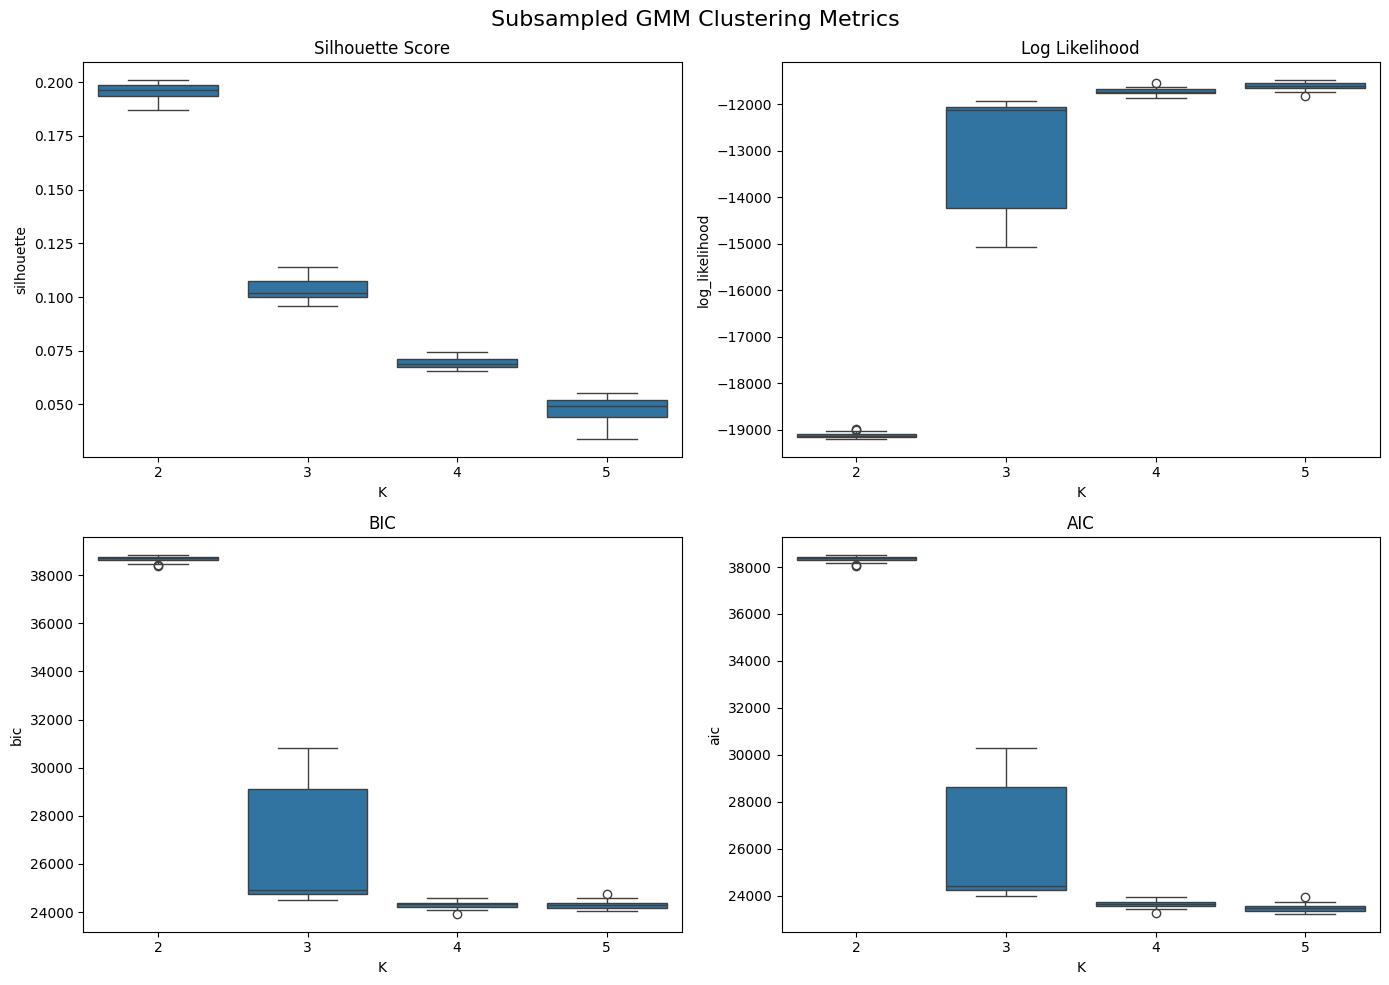

In [5]:
# ------------------------------
# 3. Visualize Metrics
# ------------------------------
metrics_df = pd.DataFrame(results)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=metrics_df, x="K", y="silhouette", ax=axs[0, 0])
axs[0, 0].set_title("Silhouette Score")
sns.boxplot(data=metrics_df, x="K", y="log_likelihood", ax=axs[0, 1])
axs[0, 1].set_title("Log Likelihood")
sns.boxplot(data=metrics_df, x="K", y="bic", ax=axs[1, 0])
axs[1, 0].set_title("BIC")
sns.boxplot(data=metrics_df, x="K", y="aic", ax=axs[1, 1])
axs[1, 1].set_title("AIC")

plt.suptitle("Subsampled GMM Clustering Metrics", fontsize=16)
plt.tight_layout()
plt.show()

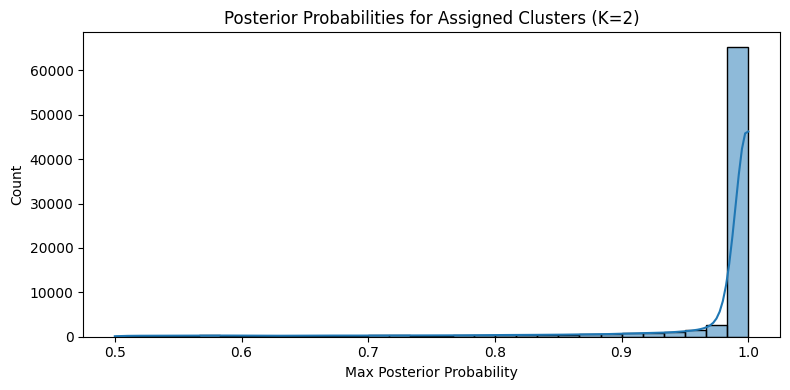

In [6]:
# ------------------------------
# 4. Cluster Stability at K=2
# ------------------------------
k_best = 2
label_matrix_k2 = []
posterior_probs_k2 = []
subsample_indices_k2 = []

for _ in range(n_subsamples):
    sample_idx = random.sample(range(len(X_cfsr)), int(sample_frac * len(X_cfsr)))
    X_sample = X_cfsr.iloc[sample_idx]

    gmm_k2 = GaussianMixture(n_components=k_best, covariance_type='full', random_state=42, n_init=5)
    gmm_k2.fit(X_sample)
    probs_k2 = gmm_k2.predict_proba(X_sample)
    labels_k2 = gmm_k2.predict(X_sample)

    label_matrix_k2.append(labels_k2)
    posterior_probs_k2.append(probs_k2.max(axis=1))
    subsample_indices_k2.append(sample_idx)

# Plot histogram of posterior max probabilities
plt.figure(figsize=(8, 4))
all_probs_k2 = np.concatenate(posterior_probs_k2)
sns.histplot(all_probs_k2, bins=30, kde=True)
plt.title(f"Posterior Probabilities for Assigned Clusters (K={k_best})")
plt.xlabel("Max Posterior Probability")
plt.tight_layout()
plt.show()

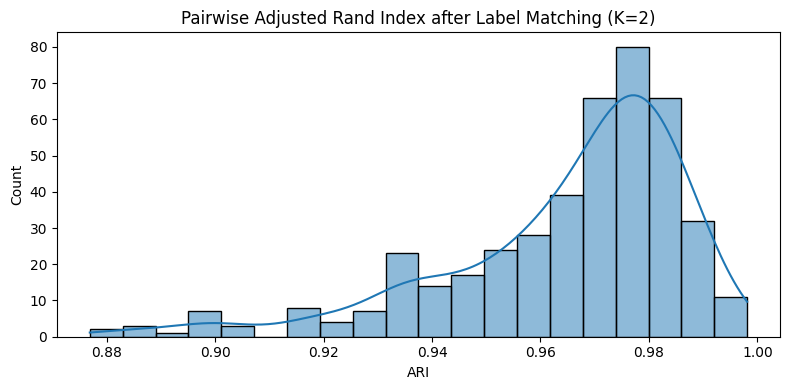

In [7]:
mapped_ari_scores_k2 = []
n_runs = len(label_matrix_k2)

for i in range(n_runs):
    for j in range(i + 1, n_runs):
        idx_i = subsample_indices_k2[i]
        idx_j = subsample_indices_k2[j]

        shared_idx = list(set(idx_i) & set(idx_j))
        if not shared_idx:
            continue

        # positions of shared indices within each subsample list
        pos_i = [idx_i.index(x) for x in shared_idx]
        pos_j = [idx_j.index(x) for x in shared_idx]

        labels_i = label_matrix_k2[i][pos_i]
        labels_j = label_matrix_k2[j][pos_j]

        ari = adjusted_rand_score(labels_i, labels_j)  # label-invariant
        mapped_ari_scores_k2.append(ari)

# plot histogram
plt.figure(figsize=(8, 4))
sns.histplot(mapped_ari_scores_k2, bins=20, kde=True)
plt.title(f"Pairwise Adjusted Rand Index after Label Matching (K={k_best})")
plt.xlabel("ARI")
plt.tight_layout()
plt.show()

In [24]:
# Fit on full dataset for K=2
final_gmm_k2 = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42,
    n_init=5
)
final_gmm_k2.fit(X_cfsr_scaled)

df_cfsr['k2_cluster'] = final_gmm_k2.predict(X_cfsr_scaled)
df_cfsr['k2_posterior'] = final_gmm_k2.predict_proba(X_cfsr_scaled).max(axis=1)

# --- Save labeled dataframe ---
out_csv = os.path.join(OUT_DIR, "cfsr_storms_labeled_k2.csv")
df_cfsr.to_csv(out_csv, index=False)

# --- Save model artifacts ---
joblib.dump(scaler, os.path.join(OUT_DIR, "scaler.joblib"))
joblib.dump(final_gmm_k2, os.path.join(OUT_DIR, "final_gmm_k2.joblib"))

with open(os.path.join(OUT_DIR, "features.json"), "w") as f:
    json.dump(features_to_cluster, f, indent=2)

print("Saved: cfsr_storms_labeled_k2.csv, scaler.joblib, final_gmm_k2.joblib, features.json")


Saved: cfsr_storms_labeled_k2.csv, scaler.joblib, final_gmm_k2.joblib, features.json


In [ ]:
# PCA
pca = PCA(n_components=2)
X_pca_refined = pca.fit_transform(X_cfsr_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca_refined[:, 0], y=X_pca_refined[:, 1], hue=df_cfsr['k2_cluster'], palette='tab10', s=20)
plt.title("PCA Projection (K=2 Refined)")
plt.tight_layout()
plt.show()

In [ ]:
# PCA
pca = PCA(n_components=2)
X_pca_refined = pca.fit_transform(X_cfsr_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca_refined[:, 0], y=X_pca_refined[:, 1], hue=df_cfsr['k2_posterior'], palette='tab10', s=20)
plt.title("PCA Projection (K=2 Refined)")
plt.tight_layout()
plt.show()

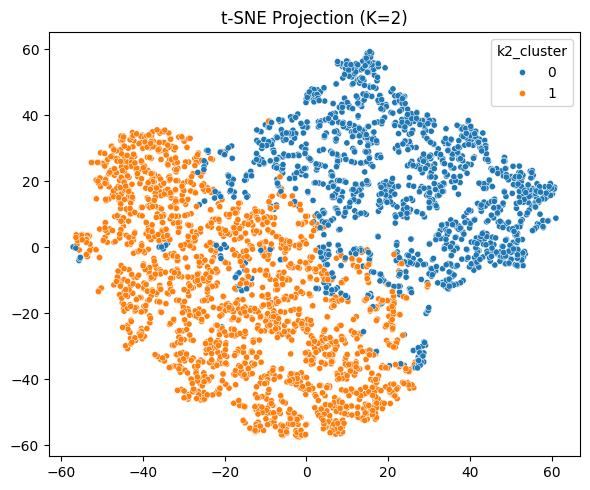

In [26]:

# t-SNE
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_cfsr_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df_cfsr['k2_cluster'], palette='tab10', s=20)
plt.title("t-SNE Projection (K=2)")
plt.tight_layout()
plt.show()
